## This notebook is reproducing the plots shown in section 2.2 in the paper

In [ ]:
import sys
from pathlib import Path
sys.path.append('../')


from matching_clustering.utils import LapOT
import numpy as np
import matplotlib.pyplot as plt


### Begin by plotting the data. Point clouds $X$ and $Y$ both with 30 points, separated into 3 natural clusters, each point in either cloud colored into either green, red of blue.

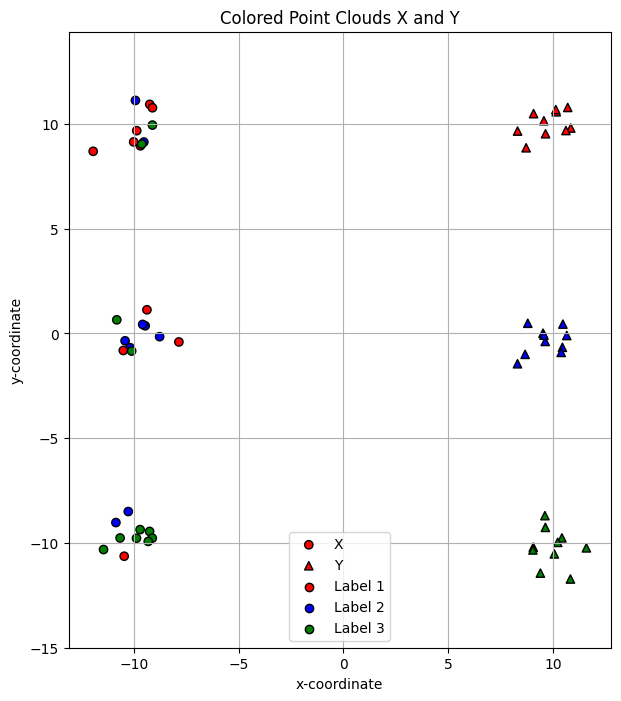

In [5]:
rng = np.random.default_rng(42)

n_per_cluster = 10
std = 1

x_means = np.array([
    [-10,  10],
    [-10,   0],
    [-10, -10]
])

y_means = np.array([
    [10,  10],
    [10,   0],
    [10, -10]
])

X = np.vstack([
    rng.normal(loc=mean, scale=std, size=(n_per_cluster, 2))
    for mean in x_means
])

Y = np.vstack([
    rng.normal(loc=mean, scale=std, size=(n_per_cluster, 2))
    for mean in y_means
])

# Labels:
# 1 = red, 2 = blue, 3 = green

Y_labels = np.array(
    [1] * 10 +
    [2] * 10 +
    [3] * 10
)

X_labels = np.array(
    # First 10 X points: 6 red, 2 blue, 2 green
    [1] * 6 + [2] * 2 + [3] * 2 +

    # Second 10 X points: 5 blue, 3 red, 2 green
    [2] * 5 + [1] * 3 + [3] * 2 +

    # Last 10 X points: 7 green, 1 red, 2 blue
    [3] * 7 + [1] * 1 + [2] * 2
)

color_map = {
    1: "red",
    2: "blue",
    3: "green"
}

X_colors = [color_map[label] for label in X_labels]
Y_colors = [color_map[label] for label in Y_labels]

plt.figure(figsize=(7, 8))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=X_colors,
    marker="o",
    edgecolors="black",
    label="X"
)

plt.scatter(
    Y[:, 0],
    Y[:, 1],
    c=Y_colors,
    marker="^",
    edgecolors="black",
    label="Y"
)

plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.title("Colored Point Clouds X and Y")
plt.grid(True)
plt.axis("equal")

# Custom legend
for label, color in color_map.items():
    plt.scatter([], [], c=color, edgecolors="black", label=f"Label {label}")



plt.legend()
plt.show()

### Next, calculate and plot the transportation cost matrix $C$ reflecting the color match between the clouds


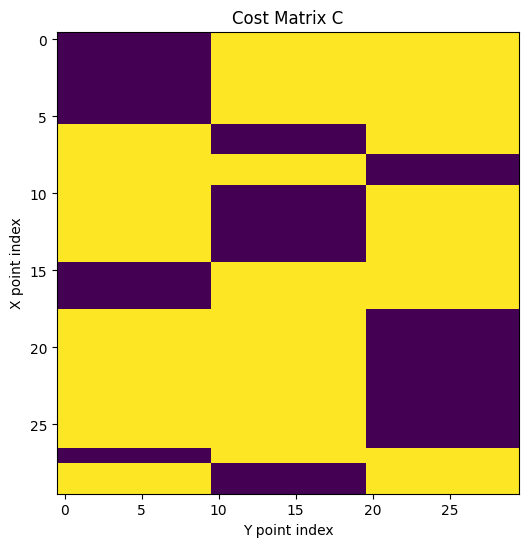

In [ ]:
C = (X_labels[:, None] != Y_labels[None, :]).astype(int)


# Set the path to save the figure
base_dir = Path.cwd()  
output_path = base_dir / "Figures" / "LapOT_example" / "Cost_matrix_C.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)


plt.figure(figsize=(7, 6))
plt.imshow(C, interpolation="nearest")

plt.xlabel("Y point index")
plt.ylabel("X point index")
plt.title("Cost Matrix C")

# plt.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0) # Uncomment to save the figure as a PDF
plt.show()

### Now, calculating and ploting the friendship matrix $K_X$ encoding the cluster partition in $X$ 

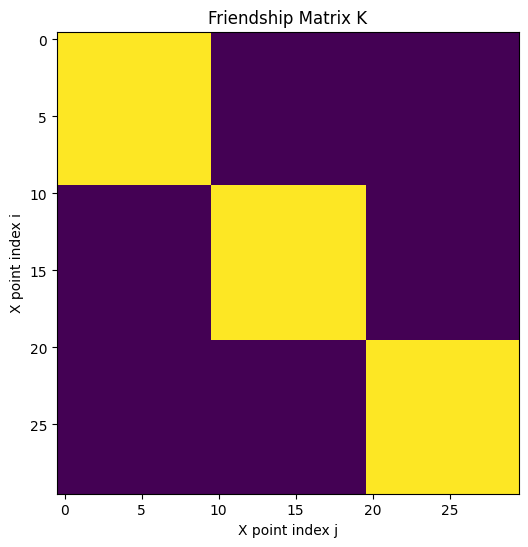

In [ ]:
X_groups = np.repeat([0, 1, 2], 10)

W = (X_groups[:, None] == X_groups[None, :]).astype(int)

# Set the path to save the figure
base_dir = Path.cwd()  
output_path = base_dir / "Figures" / "LapOT_example" / "friendship_matrix_K.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6, 6))
plt.imshow(W,  interpolation="nearest")

plt.xlabel("X point index j")
plt.ylabel("X point index i")
plt.title("Friendship Matrix K")
 
# plt.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0) # Uncomment to save the figure as a PDF

plt.show()

### Calculating the graph Laplacian $L_X$ and solving $LapOT_{w,q, \lambda_x, \lambda_y, \lambda}(C, L_X, 0)$
#### Fix $\lambda = 0.5$, $\lambda_y = 0$ and play with $\lambda_x$ 

In [8]:
degrees = W.sum(axis=1)
D = np.diag(degrees)
L = D - W

Initialization: objective = -3.2345307149954876
Implement gradient descent with KL divergence
Iteration 1: objective = -3.240584155282627, objective relative change = -0.0018715049633244007, pi change (L1) = 0.01219050106125057
Iteration 2: objective = -3.2465242041369837, objective relative change = -0.001833017928163874, pi change (L1) = 0.012128286531127283
Iteration 3: objective = -3.252350385680706, objective relative change = -0.0017945905150800886, pi change (L1) = 0.012061007538595507
Iteration 4: objective = -3.2580624038295376, objective relative change = -0.001756273916236182, pi change (L1) = 0.011988899085166897
Iteration 5: objective = -3.2636601342136737, objective relative change = -0.0017181163803236376, pi change (L1) = 0.01191219677574133
Iteration 6: objective = -3.269143615976034, objective relative change = -0.0016801632329529583, pi change (L1) = 0.01183113602507577
Iteration 7: objective = -3.274513043494898, objective relative change = -0.0016424569090890714, p

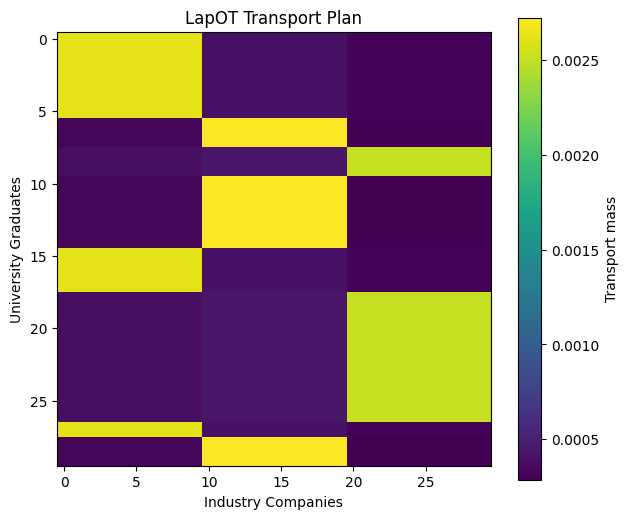

In [ ]:
prob = LapOT(L, L, C, 0.5, 25, 0)
pi = prob.solve(method='gdkl', max_iter=10000, tau_scale=1, verbose=True)


# Set the path to save the figure
base_dir = Path.cwd()  
output_path = base_dir / "Figures" / "LapOT_example" / "LapOT_solution_lambda_x_25.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Plot the transport plan and save it as a PDF
plt.figure(figsize=(7, 6))
plt.imshow(pi, interpolation="nearest")
plt.xlabel("Industry Companies")
plt.ylabel("University Graduates")
plt.title("LapOT Transport Plan")
plt.colorbar(label="Transport mass")

# plt.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0)  # Uncomment to save the figure as a PDF

plt.show()